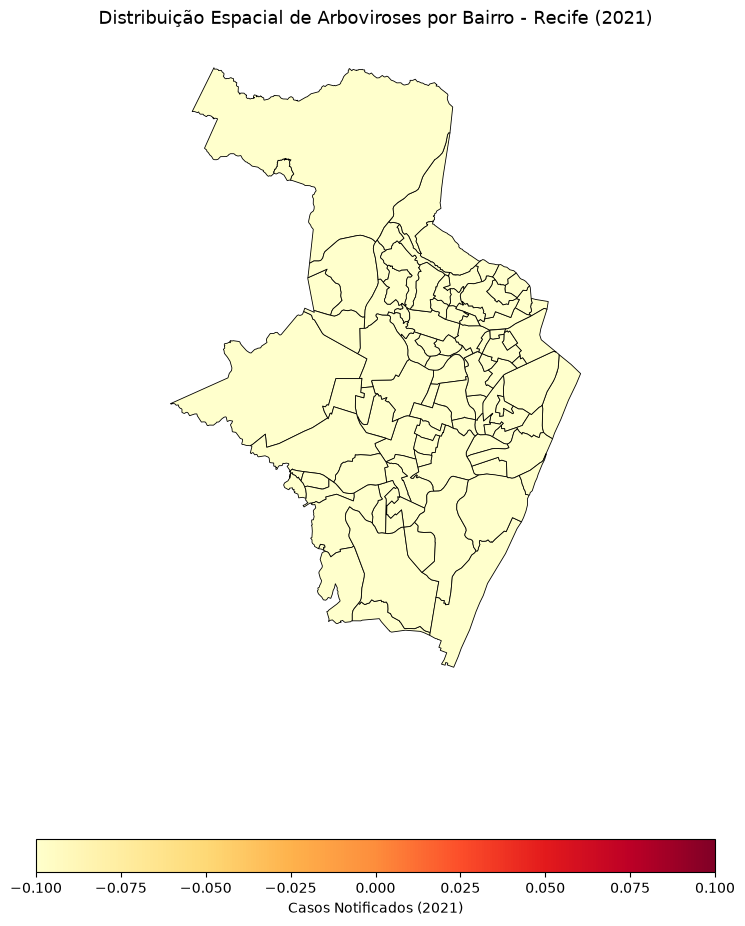

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import unicodedata
import pandas as pd

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

# 1. Carregar as bases
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
painel_path = "../data/processed/recife_arboviroses_painel.gpkg"

gdf_bairros = gpd.read_file(mesh_path)
gdf_painel = gpd.read_file(painel_path)

# 2. Identificar e normalizar o nome do bairro na malha
col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)

# 3. Filtrar ano de 2021
df_2021 = gdf_painel[gdf_painel['ano'] == 2021][['bairro_norm', 'total_casos']].drop_duplicates()

# 4. Unir os dados na geometria dos 94 bairros
gdf_mapa = gdf_bairros.merge(df_2021, on='bairro_norm', how='left')
gdf_mapa['total_casos'] = gdf_mapa['total_casos'].fillna(0)

# 5. Plotar mapa coroplético
fig, ax = plt.subplots(figsize=(10, 10))

gdf_mapa.plot(
    column='total_casos',
    cmap='YlOrRd',
    linewidth=0.6,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Casos Notificados (2021)", 'orientation': "horizontal", 'shrink': 0.7},
    ax=ax
)

ax.set_title("Distribuição Espacial de Arboviroses por Bairro - Recife (2021)", fontsize=13, pad=10)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import glob

files = sorted(glob.glob("../data/raw/arboviroses_*.csv"))
for f in files:
    ano = f.split("_")[-1].replace(".csv", "")
    try:
        df_temp = pd.read_csv(f, sep=";", nrows=2, encoding="latin1")
        if len(df_temp.columns) <= 1:
            df_temp = pd.read_csv(f, sep=",", nrows=2, encoding="latin1")
    except:
        df_temp = pd.read_csv(f, sep=";", nrows=2, encoding="utf-8")
    
    # Listar colunas que mencionam bairro, local ou distrito
    cols_loc = [c for c in df_temp.columns if any(k in c.lower() for k in ["bair", "loc", "dist", "mun", "ende", "nm_"])]
    print(f"[{ano}] Colunas encontradas:", cols_loc)

[2015] Colunas encontradas: ['co_municipio_notificacao', 'co_municipio_residencia', 'co_distrito_residencia', 'co_bairro_residencia', 'no_bairro_residencia', 'auto_imune', 'tp_result_imunohistoquimica', 'co_municipio_hospital', 'co_municipio_infeccao', 'co_distrito_infeccao', 'co_bairro_infeccao', 'no_bairro_infeccao']
[2016] Colunas encontradas: ['co_municipio_notificacao', 'co_municipio_residencia', 'co_distrito_residencia', 'co_bairro_residencia', 'no_bairro_residencia', 'auto_imune', 'tp_result_imunohistoquimica', 'co_municipio_hospital', 'co_municipio_infeccao', 'co_distrito_infeccao', 'co_bairro_infeccao', 'no_bairro_infeccao']
[2017] Colunas encontradas: ['co_municipio_notificacao', 'co_municipio_residencia', 'co_distrito_residencia', 'co_bairro_residencia', 'no_bairro_residencia', 'auto_imune', 'tp_result_imunohistoquimica', 'co_municipio_hospital', 'co_municipio_infeccao', 'co_distrito_infeccao', 'co_bairro_infeccao', 'no_bairro_infeccao']
[2018] Colunas encontradas: ['co_muni

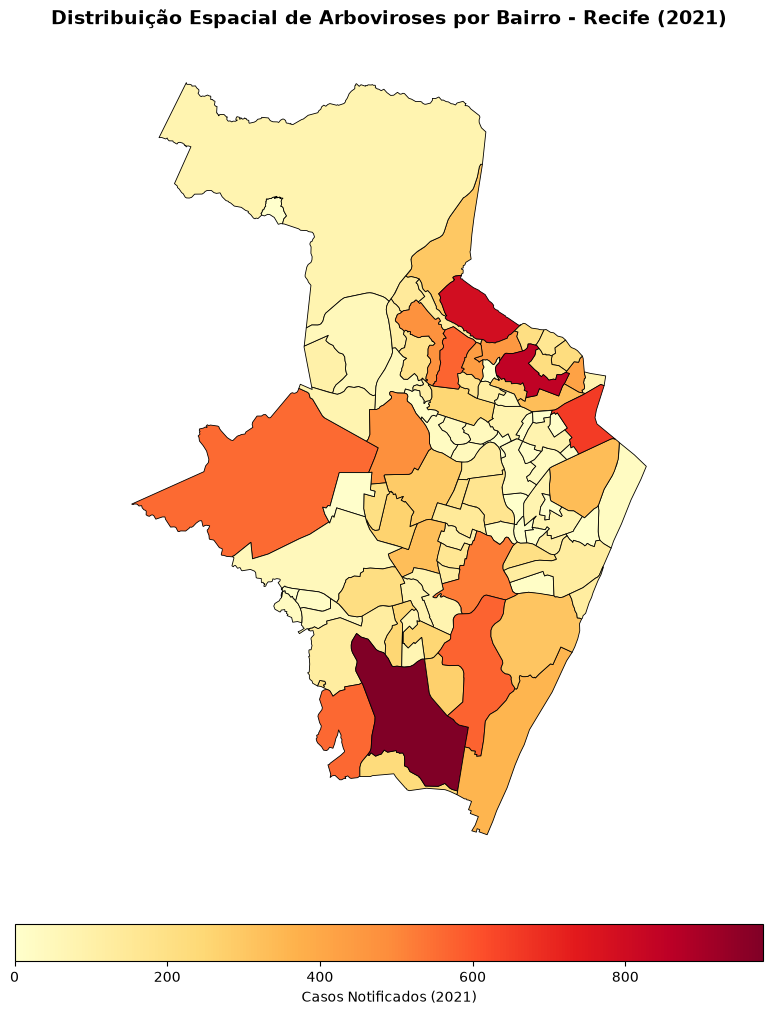

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import unicodedata
import pandas as pd

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

# 1. Carregar os dados
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
painel_path = "../data/processed/recife_arboviroses_painel.gpkg"

gdf_bairros = gpd.read_file(mesh_path)
gdf_painel = gpd.read_file(painel_path)

col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)

# 2. Filtrar o ano de 2021 (pico da série)
df_2021 = gdf_painel[gdf_painel['ano'] == 2021][['bairro_norm', 'total_casos']].drop_duplicates()

gdf_mapa = gdf_bairros.merge(df_2021, on='bairro_norm', how='left')
gdf_mapa['total_casos'] = gdf_mapa['total_casos'].fillna(0)

# 3. Plotar o mapa coroplético com gradiente de calor
fig, ax = plt.subplots(figsize=(11, 11))

gdf_mapa.plot(
    column='total_casos',
    cmap='YlOrRd',
    linewidth=0.6,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': "Casos Notificados (2021)", 'orientation': "horizontal", 'shrink': 0.7, 'pad': 0.05},
    ax=ax
)

ax.set_title("Distribuição Espacial de Arboviroses por Bairro - Recife (2021)", fontsize=14, weight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [6]:
import folium
import geopandas as gpd
import unicodedata
import pandas as pd

# 1. Carregar malha e dados
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
painel_path = "../data/processed/recife_arboviroses_painel.gpkg"

gdf_bairros = gpd.read_file(mesh_path)
gdf_painel = gpd.read_file(painel_path)

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)

# 2. Filtrar o ano de 2021 e consolidar atributos
df_2021 = gdf_painel[gdf_painel["ano"] == 2021][["bairro_norm", "total_casos"]].drop_duplicates()
gdf_mapa = gdf_bairros.merge(df_2021, on="bairro_norm", how="left")
gdf_mapa["total_casos"] = gdf_mapa["total_casos"].fillna(0).astype(int)

# Garantir projeção geográfica padrão (WGS84 - EPSG:4326) para o Leaflet
gdf_mapa = gdf_mapa.to_crs(epsg=4326)

# 3. Inicializar o mapa centrado no Recife
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles="CartoDB positron"
)

# 4. Criar a camada coroplética interativa
folium.Choropleth(
    geo_data=gdf_mapa,
    name="Casos 2021",
    data=gdf_mapa,
    columns=["bairro_norm", "total_casos"],
    key_on="feature.properties.bairro_norm",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Notificações de Arboviroses (2021)"
).add_to(m)

# 5. Adicionar Tooltip ao passar o cursor por cima dos bairros
tooltip = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos"],
    aliases=["Bairro:", "Casos Notificados:"],
    localize=True,
    sticky=False,
    style="""
        background-color: #F0EFEF;
        border: 1px solid black;
        border-radius: 4px;
        box-shadow: 2px 2px 2px grey;
        font-family: sans-serif;
        font-size: 12px;
    """
)

folium.GeoJson(
    gdf_mapa,
    style_function=lambda x: {"fillColor": "transparent", "color": "transparent"},
    tooltip=tooltip
).add_to(m)

folium.LayerControl().add_to(m)

# Exibir o mapa no notebook
m

In [7]:
import folium
import geopandas as gpd
import unicodedata
import pandas as pd

# 1. Carregar malha e dados
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
painel_path = "../data/processed/recife_arboviroses_painel.gpkg"

gdf_bairros = gpd.read_file(mesh_path)
gdf_painel = gpd.read_file(painel_path)

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)

# 2. Filtrar o ano de 2021 e consolidar atributos
df_2021 = gdf_painel[gdf_painel["ano"] == 2021][["bairro_norm", "total_casos"]].drop_duplicates()
gdf_mapa = gdf_bairros.merge(df_2021, on="bairro_norm", how="left")
gdf_mapa["total_casos"] = gdf_mapa["total_casos"].fillna(0).astype(int)

# 3. Converter para coordenadas geográficas padrão (EPSG:4326)
gdf_mapa = gdf_mapa.to_crs(epsg=4326)

# 4. Inicializar o mapa centrado no Recife
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles="CartoDB positron"
)

# 5. Criar a camada coroplética interativa
folium.Choropleth(
    geo_data=gdf_mapa,
    name="Casos 2021",
    data=gdf_mapa,
    columns=["bairro_norm", "total_casos"],
    key_on="feature.properties.bairro_norm",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Notificações de Arboviroses (2021)"
).add_to(m)

# 6. Adicionar pop-up/tooltip ao passar o mouse
tooltip = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos"],
    aliases=["Bairro:", "Casos Notificados:"],
    localize=True,
    sticky=False,
    style="""
        background-color: #F0EFEF;
        border: 1px solid black;
        border-radius: 4px;
        box-shadow: 2px 2px 2px grey;
        font-family: sans-serif;
        font-size: 12px;
    """
)

folium.GeoJson(
    gdf_mapa,
    style_function=lambda x: {"fillColor": "transparent", "color": "transparent"},
    tooltip=tooltip
).add_to(m)

folium.LayerControl().add_to(m)

# Exibir o mapa na saída da célula
m

In [8]:
import folium
import geopandas as gpd
import unicodedata
import pandas as pd

# 1. Carregar malha e dados
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
painel_path = "../data/processed/recife_arboviroses_painel.gpkg"

gdf_bairros = gpd.read_file(mesh_path)
gdf_painel = gpd.read_file(painel_path)

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)

# 2. Filtrar o ano de 2021 e consolidar atributos
df_2021 = gdf_painel[gdf_painel["ano"] == 2021][["bairro_norm", "total_casos"]].drop_duplicates()
gdf_mapa = gdf_bairros.merge(df_2021, on="bairro_norm", how="left")
gdf_mapa["total_casos"] = gdf_mapa["total_casos"].fillna(0).astype(int)

# 3. Converter para coordenadas geográficas padrão (EPSG:4326)
gdf_mapa = gdf_mapa.to_crs(epsg=4326)

# 4. Inicializar o mapa centrado no Recife
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles="CartoDB positron"
)

# 5. Criar a camada coroplética interativa
folium.Choropleth(
    geo_data=gdf_mapa,
    name="Casos 2021",
    data=gdf_mapa,
    columns=["bairro_norm", "total_casos"],
    key_on="feature.properties.bairro_norm",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Notificações de Arboviroses (2021)"
).add_to(m)

# 6. Adicionar pop-up/tooltip ao passar o mouse
tooltip = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos"],
    aliases=["Bairro:", "Casos Notificados:"],
    localize=True,
    sticky=False,
    style="""
        background-color: #F0EFEF;
        border: 1px solid black;
        border-radius: 4px;
        box-shadow: 2px 2px 2px grey;
        font-family: sans-serif;
        font-size: 12px;
    """
)

folium.GeoJson(
    gdf_mapa,
    style_function=lambda x: {"fillColor": "transparent", "color": "transparent"},
    tooltip=tooltip
).add_to(m)

folium.LayerControl().add_to(m)

# 7. Salvar diretamente no arquivo HTML
output_html = "../data/processed/mapa_recife_2021.html"
m.save(output_html)
print(f"[✓] Mapa salvo com sucesso em: {output_html}")

[✓] Mapa salvo com sucesso em: ../data/processed/mapa_recife_2021.html


In [9]:
import folium
import geopandas as gpd
import unicodedata
import pandas as pd
import branca.colormap as cm

# 1. Carregar dados
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
painel_path = "../data/processed/recife_arboviroses_painel.gpkg"

gdf_bairros = gpd.read_file(mesh_path)
gdf_painel = gpd.read_file(painel_path)

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)
gdf_bairros = gdf_bairros.to_crs(epsg=4326)

# 2. Inicializar o mapa centrado no Recife (usando OpenStreetMap limpo)
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles="OpenStreetMap"
)

# 3. Criar escala de cores global compartilhada
max_casos = int(gdf_painel["total_casos"].max()) if not gdf_painel.empty else 1000
colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=0,
    vmax=max_casos,
    caption="Total de Notificações de Arboviroses"
)
colormap.add_to(m)

# 4. Criar uma camada para cada ano da série (2015 a 2024)
anos = sorted(gdf_painel["ano"].dropna().unique())

for i, ano in enumerate(anos):
    df_ano = gdf_painel[gdf_painel["ano"] == ano][["bairro_norm", "total_casos"]].drop_duplicates()
    gdf_ano = gdf_bairros.merge(df_ano, on="bairro_norm", how="left")
    gdf_ano["total_casos"] = gdf_ano["total_casos"].fillna(0).astype(int)
    
    # Define se a camada começa visível (deixa o último ano ativo por padrão)
    show_layer = (i == len(anos) - 1)
    
    fg = folium.FeatureGroup(name=f"Ano {int(ano)}", show=show_layer)
    
    tooltip = folium.GeoJsonTooltip(
        fields=[col_nome, "total_casos"],
        aliases=["Bairro:", f"Casos ({int(ano)}):"],
        localize=True,
        sticky=False,
        style="background-color: #ffffff; border: 1px solid black; border-radius: 4px; padding: 5px; font-family: sans-serif; font-size: 12px;"
    )
    
    folium.GeoJson(
        gdf_ano,
        style_function=lambda feature, cmap=colormap: {
            "fillColor": cmap(feature["properties"]["total_casos"]),
            "color": "black",
            "weight": 0.6,
            "fillOpacity": 0.75,
        },
        tooltip=tooltip
    ).add_to(fg)
    
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# 5. Salvar o arquivo
output_html = "../data/processed/mapa_recife_temporal.html"
m.save(output_html)
print(f"[✓] Mapa multi-temporal salvo com sucesso em: {output_html}")

[✓] Mapa multi-temporal salvo com sucesso em: ../data/processed/mapa_recife_temporal.html


In [12]:
import folium
import geopandas as gpd
import unicodedata
import pandas as pd
import branca.colormap as cm

# 1. Carregar malha e dados
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
painel_path = "../data/processed/recife_arboviroses_painel.gpkg"

gdf_bairros = gpd.read_file(mesh_path)
gdf_painel = gpd.read_file(painel_path)

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)
gdf_bairros = gdf_bairros.to_crs(epsg=4326)

# 2. Inicializar o mapa sem tiles embutidos
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles=None
)

# Adicionar mapa-base completo com relevo, cidades e rotulagem
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ, TomTom, Intermap, iPC, USGS, FAO, NPS, NRCAN, GeoBase, Kadaster NL, Ordnance Survey, Esri Japan, METI, Esri China (Hong Kong), and the GIS User Community",
    name="Mapa Base (Topográfico/Cidades)",
    control=True
).add_to(m)

# 3. Criar escala de cores global
max_casos = int(gdf_painel["total_casos"].max()) if not gdf_painel.empty else 1000
colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=0,
    vmax=max_casos,
    caption="Total de Notificações de Arboviroses"
)
colormap.add_to(m)

# 4. Criar camadas anuais (2015 a 2024)
anos = sorted(gdf_painel["ano"].dropna().unique())

for i, ano in enumerate(anos):
    df_ano = gdf_painel[gdf_painel["ano"] == ano][["bairro_norm", "total_casos"]].drop_duplicates()
    gdf_ano = gdf_bairros.merge(df_ano, on="bairro_norm", how="left")
    gdf_ano["total_casos"] = gdf_ano["total_casos"].fillna(0).astype(int)
    
    show_layer = (i == len(anos) - 1)
    
    fg = folium.FeatureGroup(name=f"Ano {int(ano)}", show=show_layer)
    
    tooltip = folium.GeoJsonTooltip(
        fields=[col_nome, "total_casos"],
        aliases=["Bairro:", f"Casos ({int(ano)}):"],
        localize=True,
        sticky=False,
        style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
    )
    
    folium.GeoJson(
        gdf_ano,
        style_function=lambda feature, cmap=colormap: {
            "fillColor": cmap(feature["properties"]["total_casos"]),
            "color": "#222222",
            "weight": 0.8,
            "fillOpacity": 0.65,
        },
        tooltip=tooltip
    ).add_to(fg)
    
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# 5. Salvar o mapa
output_html = "../data/processed/mapa_recife_temporal.html"
m.save(output_html)
print(f"[✓] Mapa atualizado com sucesso em: {output_html}")

[✓] Mapa atualizado com sucesso em: ../data/processed/mapa_recife_temporal.html


In [13]:
import pandas as pd
import geopandas as gpd
import unicodedata
import glob
import os

# Função para normalizar nomes de bairros
def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

# 1. Carregar malha geográfica
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
gdf_bairros = gpd.read_file(mesh_path)
col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)

# 2. Ler todos os CSVs brutos de 2015 a 2024
arquivos_csv = sorted(glob.glob("../data/raw/*.csv"))
lista_processados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho)
    # Extrair ano do nome do arquivo (ex: arboviroses_2021.csv)
    ano = int("".join(filter(str.isdigit, nome_arquivo)))
    
    # Tenta ler com separador ';' e codificação utf-8/latin1
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
        
    df.columns = [c.lower().strip() for c in df.columns]
    
    # Identificar coluna de bairro
    col_bairro = next((c for c in df.columns if "bairro" in c and "resid" in c or c == "nm_bairro" or c == "bairro"), None)
    if not col_bairro:
        col_bairro = next((c for c in df.columns if "bairro" in c), None)
        
    # Identificar coluna de agravo/doença
    col_agravo = next((c for c in df.columns if "agravo" in c or "doenca" in c or "notific" in c or "cd_agravo" in c), None)
    
    if col_bairro and col_agravo:
        df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
        df["agravo_clean"] = df[col_agravo].astype(str).str.upper()
        
        # Categorizar doenças
        df["is_dengue"] = df["agravo_clean"].str.contains("DENG", na=False).astype(int)
        df["is_chik"] = df["agravo_clean"].str.contains("CHIK", na=False).astype(int)
        df["is_zika"] = df["agravo_clean"].str.contains("ZIKA", na=False).astype(int)
        
        # Agrupar por bairro
        agrupado = df.groupby("bairro_norm").agg(
            dengue=("is_dengue", "sum"),
            chikungunya=("is_chik", "sum"),
            zika=("is_zika", "sum"),
            total_casos=("bairro_norm", "count")
        ).reset_index()
        
        agrupado["ano"] = ano
        lista_processados.append(agrupado)

df_consolidado = pd.concat(lista_processados, ignore_index=True)

# 3. Cruzar com a malha vetorial e salvar
gdf_painel_detalhado = gdf_bairros.merge(df_consolidado, on="bairro_norm", how="right")
painel_out = "../data/processed/recife_arboviroses_painel.gpkg"
gdf_painel_detalhado.to_file(painel_out, layer="painel_anual", driver="GPKG")

print(f"[✓] Base detalhada gerada com sucesso: {painel_out}")
print(df_consolidado.head(5))

/tmp/ipykernel_28533/1049594209.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
/tmp/ipykernel_28533/1049594209.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["agravo_clean"] = df[col_agravo].astype(str).str.upper()
/tmp/ipykernel_28533/1049594209.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1

[✓] Base detalhada gerada com sucesso: ../data/processed/recife_arboviroses_painel.gpkg
  bairro_norm  dengue  chikungunya  zika  total_casos   ano
0                   0            0     0         1244  2015
1        10.0       0            0     0            7  2015
2        12.0       0            0     0            4  2015
3        13.0       0            0     0            2  2015
4        17.0       0            0     0            4  2015


/tmp/ipykernel_28533/1049594209.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
/tmp/ipykernel_28533/1049594209.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["agravo_clean"] = df[col_agravo].astype(str).str.upper()
/tmp/ipykernel_28533/1049594209.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1

In [14]:
import folium
import geopandas as gpd
import unicodedata
import pandas as pd
import branca.colormap as cm

# 1. Carregar malha e painel atualizado
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
painel_path = "../data/processed/recife_arboviroses_painel.gpkg"

gdf_bairros = gpd.read_file(mesh_path)
gdf_painel = gpd.read_file(painel_path)

col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(
    lambda x: "".join([c for c in unicodedata.normalize("NFKD", str(x).strip().upper()) if not unicodedata.combining(c)])
)
gdf_bairros = gdf_bairros.to_crs(epsg=4326)

# 2. Inicializar mapa com Esri Topo
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ",
    name="Mapa Base",
    control=False
).add_to(m)

# 3. Escala de cores
max_casos = int(gdf_painel["total_casos"].max()) if not gdf_painel.empty else 1000
colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=0,
    vmax=max_casos,
    caption="Total de Casos Notificados"
)
colormap.add_to(m)

# 4. Criar Camada de TOTAL ACUMULADO (2015-2024)
df_acumulado = gdf_painel.groupby("bairro_norm").agg(
    dengue=("dengue", "sum"),
    chikungunya=("chikungunya", "sum"),
    zika=("zika", "sum"),
    total_casos=("total_casos", "sum")
).reset_index()

gdf_acumulado = gdf_bairros.merge(df_acumulado, on="bairro_norm", how="left").fillna(0)
for c in ["dengue", "chikungunya", "zika", "total_casos"]:
    gdf_acumulado[c] = gdf_acumulado[c].astype(int)

fg_acumulado = folium.FeatureGroup(name="★ Total Acumulado (2015-2024)", show=True)

tooltip_acumulado = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
    aliases=["Bairro:", "Total Geral:", "• Dengue:", "• Chikungunya:", "• Zika:"],
    localize=True,
    sticky=False,
    style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
)

folium.GeoJson(
    gdf_acumulado,
    style_function=lambda feature, cmap=colormap: {
        "fillColor": cmap(feature["properties"]["total_casos"]),
        "color": "#222222",
        "weight": 0.8,
        "fillOpacity": 0.65,
    },
    tooltip=tooltip_acumulado
).add_to(fg_acumulado)
fg_acumulado.add_to(m)

# 5. Criar Camadas Anuais (2015 a 2024)
anos = sorted(gdf_painel["ano"].dropna().unique())

for ano in anos:
    df_ano = gdf_painel[gdf_painel["ano"] == ano][["bairro_norm", "dengue", "chikungunya", "zika", "total_casos"]].drop_duplicates()
    gdf_ano = gdf_bairros.merge(df_ano, on="bairro_norm", how="left").fillna(0)
    for c in ["dengue", "chikungunya", "zika", "total_casos"]:
        gdf_ano[c] = gdf_ano[c].astype(int)
    
    fg = folium.FeatureGroup(name=f"Ano {int(ano)}", show=False)
    
    tooltip = folium.GeoJsonTooltip(
        fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
        aliases=["Bairro:", f"Total ({int(ano)}):", "• Dengue:", "• Chikungunya:", "• Zika:"],
        localize=True,
        sticky=False,
        style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
    )
    
    folium.GeoJson(
        gdf_ano,
        style_function=lambda feature, cmap=colormap: {
            "fillColor": cmap(feature["properties"]["total_casos"]),
            "color": "#222222",
            "weight": 0.8,
            "fillOpacity": 0.65,
        },
        tooltip=tooltip
    ).add_to(fg)
    
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# 6. Salvar mapa
output_html = "../data/processed/mapa_recife_temporal.html"
m.save(output_html)
print(f"[✓] Mapa atualizado com sucesso em: {output_html}")

/home/lunyel/arboviroses-recife/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'recife_arboviroses_painel.gpkg': 'recife_arboviroses_painel' (default), 'painel_anual'. Specify layer parameter to avoid this warning.
  result = read_func(


KeyError: "Label(s) ['chikungunya', 'dengue', 'zika'] do not exist"

In [15]:
import glob
import pandas as pd

arquivos = sorted(glob.glob("../data/raw/*.csv"))
print("Arquivos encontrados:", arquivos)

if arquivos:
    try:
        df_exemplo = pd.read_csv(arquivos[0], sep=";", nrows=5, encoding="utf-8")
    except:
        df_exemplo = pd.read_csv(arquivos[0], sep=";", nrows=5, encoding="latin1")
        
    print(f"\nColunas presentes no primeiro arquivo ({arquivos[0]}):")
    print(list(df_exemplo.columns))
    print("\nPrimeiras 2 linhas:")
    print(df_exemplo.head(2))

Arquivos encontrados: ['../data/raw/arboviroses_2015.csv', '../data/raw/arboviroses_2016.csv', '../data/raw/arboviroses_2017.csv', '../data/raw/arboviroses_2018.csv', '../data/raw/arboviroses_2019.csv', '../data/raw/arboviroses_2020.csv', '../data/raw/arboviroses_2021.csv', '../data/raw/arboviroses_2022.csv', '../data/raw/arboviroses_2023.csv', '../data/raw/arboviroses_2024.csv']

Colunas presentes no primeiro arquivo (../data/raw/arboviroses_2015.csv):
['nu_notificacao', 'tp_notificacao', 'co_cid', 'dt_notificacao', 'ds_semana_notificacao', 'notificacao_ano', 'co_uf_notificacao', 'co_municipio_notificacao', 'id_regional', 'co_unidade_notificacao', 'dt_diagnostico_sintoma', 'ds_semana_sintoma', 'dt_nascimento', 'nu_idade', 'tp_sexo', 'tp_gestante', 'tp_raca_cor', 'tp_escolaridade', 'co_uf_residencia', 'co_municipio_residencia', 'co_regional_residencia', 'co_distrito_residencia', 'co_bairro_residencia', 'no_bairro_residencia', 'co_logradouro_residencia', 'nome_logradouro_residencia', 'n

In [16]:
import pandas as pd
import geopandas as gpd
import unicodedata
import glob
import os

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

# 1. Carregar malha
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
gdf_bairros = gpd.read_file(mesh_path)
col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)

# 2. Processar CSVs
arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))
lista_processados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho)
    ano = int("".join(filter(str.isdigit, nome_arquivo)))
    
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
        
    df.columns = [c.lower().strip() for c in df.columns]
    
    col_bairro = "no_bairro_residencia" if "no_bairro_residencia" in df.columns else None
    col_cid = "co_cid" if "co_cid" in df.columns else None
    
    if col_bairro and col_cid:
        # Filtrar apenas residentes de Recife se houver coluna de município
        if "co_municipio_residencia" in df.columns:
            df = df[df["co_municipio_residencia"].astype(str).str.startswith("261160") | df["co_municipio_residencia"].isna()]
            
        df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
        df["cid_clean"] = df[col_cid].astype(str).str.upper().str.strip()
        
        # Mapeamento oficial CID-10
        # Dengue: A90, A91
        # Chikungunya: A92.0 ou A92 (em bases que agregam A92 como chikungunya)
        # Zika: A92.8, A928, U06, U069
        df["is_dengue"] = df["cid_clean"].str.startswith(("A90", "A91")).astype(int)
        df["is_chik"] = df["cid_clean"].str.startswith(("A920", "A92.0", "A92")).astype(int) & (~df["cid_clean"].str.startswith(("A928", "A92.8")))
        df["is_zika"] = df["cid_clean"].str.startswith(("A928", "A92.8", "U06")).astype(int)
        
        agrupado = df.groupby("bairro_norm").agg(
            dengue=("is_dengue", "sum"),
            chikungunya=("is_chik", "sum"),
            zika=("is_zika", "sum"),
            total_casos=("bairro_norm", "count")
        ).reset_index()
        
        agrupado["ano"] = ano
        lista_processados.append(agrupado)

df_consolidado = pd.concat(lista_processados, ignore_index=True)

# 3. Salvar GeoPackage consolidado
gdf_painel_detalhado = gdf_bairros.merge(df_consolidado, on="bairro_norm", how="right")
painel_out = "../data/processed/recife_arboviroses_painel.gpkg"
gdf_painel_detalhado.to_file(painel_out, layer="painel_anual", driver="GPKG")

print(f"[✓] Base detalhada gerada com sucesso: {painel_out}")
print(df_consolidado.head(5))

/tmp/ipykernel_28533/3784097746.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
/tmp/ipykernel_28533/3784097746.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cid_clean"] = df[col_cid].astype(str).str.upper().str.strip()
/tmp/ipykernel_28533/3784097746.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

[✓] Base detalhada gerada com sucesso: ../data/processed/recife_arboviroses_painel.gpkg
     bairro_norm  dengue  chikungunya  zika  total_casos   ano
0                      0         1236     0         1236  2015
1        AFLITOS       0            2     0            2  2015
2       AFOGADOS       0            8     0            8  2015
3      AGUA FRIA       0           27     0           27  2015
4  ALTO DO MANDU       0            2     0            2  2015


In [17]:
import folium
import geopandas as gpd
import unicodedata
import pandas as pd
import branca.colormap as cm

# 1. Carregar malha e painel
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
painel_path = "../data/processed/recife_arboviroses_painel.gpkg"

gdf_bairros = gpd.read_file(mesh_path)
gdf_painel = gpd.read_file(painel_path)

col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(
    lambda x: "".join([c for c in unicodedata.normalize("NFKD", str(x).strip().upper()) if not unicodedata.combining(c)])
)
gdf_bairros = gdf_bairros.to_crs(epsg=4326)

# 2. Inicializar mapa
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ",
    name="Mapa Base",
    control=False
).add_to(m)

# 3. Escala de cores
max_casos = int(gdf_painel["total_casos"].max()) if not gdf_painel.empty else 1000
colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=0,
    vmax=max_casos,
    caption="Total de Casos Notificados"
)
colormap.add_to(m)

# 4. Camada de Total Acumulado (2015-2024)
df_acumulado = gdf_painel.groupby("bairro_norm").agg(
    dengue=("dengue", "sum"),
    chikungunya=("chikungunya", "sum"),
    zika=("zika", "sum"),
    total_casos=("total_casos", "sum")
).reset_index()

gdf_acumulado = gdf_bairros.merge(df_acumulado, on="bairro_norm", how="left").fillna(0)
for c in ["dengue", "chikungunya", "zika", "total_casos"]:
    gdf_acumulado[c] = gdf_acumulado[c].astype(int)

fg_acumulado = folium.FeatureGroup(name="★ Total Acumulado (2015-2024)", show=True)

tooltip_acumulado = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
    aliases=["Bairro:", "Total Geral:", "• Dengue:", "• Chikungunya:", "• Zika:"],
    localize=True,
    sticky=False,
    style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
)

folium.GeoJson(
    gdf_acumulado,
    style_function=lambda feature, cmap=colormap: {
        "fillColor": cmap(feature["properties"]["total_casos"]),
        "color": "#222222",
        "weight": 0.8,
        "fillOpacity": 0.65,
    },
    tooltip=tooltip_acumulado
).add_to(fg_acumulado)
fg_acumulado.add_to(m)

# 5. Camadas Anuais (2015 a 2024)
anos = sorted(gdf_painel["ano"].dropna().unique())

for ano in anos:
    df_ano = gdf_painel[gdf_painel["ano"] == ano][["bairro_norm", "dengue", "chikungunya", "zika", "total_casos"]].drop_duplicates()
    gdf_ano = gdf_bairros.merge(df_ano, on="bairro_norm", how="left").fillna(0)
    for c in ["dengue", "chikungunya", "zika", "total_casos"]:
        gdf_ano[c] = gdf_ano[c].astype(int)
    
    fg = folium.FeatureGroup(name=f"Ano {int(ano)}", show=False)
    
    tooltip = folium.GeoJsonTooltip(
        fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
        aliases=["Bairro:", f"Total ({int(ano)}):", "• Dengue:", "• Chikungunya:", "• Zika:"],
        localize=True,
        sticky=False,
        style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
    )
    
    folium.GeoJson(
        gdf_ano,
        style_function=lambda feature, cmap=colormap: {
            "fillColor": cmap(feature["properties"]["total_casos"]),
            "color": "#222222",
            "weight": 0.8,
            "fillOpacity": 0.65,
        },
        tooltip=tooltip
    ).add_to(fg)
    
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# 6. Salvar mapa
output_html = "../data/processed/mapa_recife_temporal.html"
m.save(output_html)
print(f"[✓] Mapa atualizado com sucesso em: {output_html}")

/home/lunyel/arboviroses-recife/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'recife_arboviroses_painel.gpkg': 'recife_arboviroses_painel' (default), 'painel_anual'. Specify layer parameter to avoid this warning.
  result = read_func(


KeyError: "Label(s) ['chikungunya', 'dengue', 'zika'] do not exist"

In [18]:
import glob
import os
import unicodedata
import branca.colormap as cm
import folium
import geopandas as gpd
import pandas as pd

# 1. Função de normalização textual
def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

# 2. Carregar malha geográfica
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
gdf_bairros = gpd.read_file(mesh_path)
col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)
gdf_bairros = gdf_bairros.to_crs(epsg=4326)

# 3. Processar todos os CSVs brutos (2015 a 2024)
arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))
lista_processados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho)
    ano = int("".join(filter(str.isdigit, nome_arquivo)))
    
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
        
    df.columns = [c.lower().strip() for c in df.columns]
    
    col_bairro = "no_bairro_residencia" if "no_bairro_residencia" in df.columns else None
    col_cid = "co_cid" if "co_cid" in df.columns else None
    
    if col_bairro and col_cid:
        # Filtrar município do Recife se o código estiver presente
        if "co_municipio_residencia" in df.columns:
            df = df[df["co_municipio_residencia"].astype(str).str.startswith("261160") | df["co_municipio_residencia"].isna()]
            
        df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
        df["cid_clean"] = df[col_cid].astype(str).str.upper().str.strip()
        
        # Mapeamento CID-10
        # Dengue: A90, A91 | Chikungunya: A92, A92.0 | Zika: A92.8, U06
        df["is_dengue"] = df["cid_clean"].str.startswith(("A90", "A91")).astype(int)
        df["is_chik"] = df["cid_clean"].str.startswith(("A920", "A92.0", "A92")).astype(int) & (~df["cid_clean"].str.startswith(("A928", "A92.8")))
        df["is_zika"] = df["cid_clean"].str.startswith(("A928", "A92.8", "U06")).astype(int)
        
        agrupado = df.groupby("bairro_norm").agg(
            dengue=("is_dengue", "sum"),
            chikungunya=("is_chik", "sum"),
            zika=("is_zika", "sum"),
            total_casos=("bairro_norm", "count")
        ).reset_index()
        
        agrupado["ano"] = ano
        lista_processados.append(agrupado)

df_painel = pd.concat(lista_processados, ignore_index=True)

# Salvar base consolidada para análises futuras
gdf_painel_detalhado = gdf_bairros.merge(df_painel, on="bairro_norm", how="right")
gdf_painel_detalhado.to_file("../data/processed/recife_arboviroses_painel.gpkg", driver="GPKG")

# 4. Inicializar mapa com Esri Topo
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ",
    name="Mapa Base",
    control=False
).add_to(m)

# 5. Escala de cores unificada
max_casos = int(df_painel["total_casos"].max()) if not df_painel.empty else 1000
colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=0,
    vmax=max_casos,
    caption="Total de Notificações de Arboviroses"
)
colormap.add_to(m)

# 6. Camada: Total Acumulado (2015-2024)
df_acumulado = df_painel.groupby("bairro_norm").agg(
    dengue=("dengue", "sum"),
    chikungunya=("chikungunya", "sum"),
    zika=("zika", "sum"),
    total_casos=("total_casos", "sum")
).reset_index()

gdf_acumulado = gdf_bairros.merge(df_acumulado, on="bairro_norm", how="left").fillna(0)
for col in ["dengue", "chikungunya", "zika", "total_casos"]:
    gdf_acumulado[col] = gdf_acumulado[col].astype(int)

fg_acumulado = folium.FeatureGroup(name="★ Total Acumulado (2015-2024)", show=True)

tooltip_acumulado = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
    aliases=["Bairro:", "Total Geral:", "• Dengue:", "• Chikungunya:", "• Zika:"],
    localize=True,
    sticky=False,
    style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
)

folium.GeoJson(
    gdf_acumulado,
    style_function=lambda feature, cmap=colormap: {
        "fillColor": cmap(feature["properties"]["total_casos"]),
        "color": "#222222",
        "weight": 0.8,
        "fillOpacity": 0.65,
    },
    tooltip=tooltip_acumulado
).add_to(fg_acumulado)
fg_acumulado.add_to(m)

# 7. Camadas: Anos Individuais (2015 a 2024)
anos = sorted(df_painel["ano"].dropna().unique())

for ano in anos:
    df_ano = df_painel[df_painel["ano"] == ano][["bairro_norm", "dengue", "chikungunya", "zika", "total_casos"]].drop_duplicates()
    gdf_ano = gdf_bairros.merge(df_ano, on="bairro_norm", how="left").fillna(0)
    for col in ["dengue", "chikungunya", "zika", "total_casos"]:
        gdf_ano[col] = gdf_ano[col].astype(int)
    
    fg = folium.FeatureGroup(name=f"Ano {int(ano)}", show=False)
    
    tooltip = folium.GeoJsonTooltip(
        fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
        aliases=["Bairro:", f"Total ({int(ano)}):", "• Dengue:", "• Chikungunya:", "• Zika:"],
        localize=True,
        sticky=False,
        style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
    )
    
    folium.GeoJson(
        gdf_ano,
        style_function=lambda feature, cmap=colormap: {
            "fillColor": cmap(feature["properties"]["total_casos"]),
            "color": "#222222",
            "weight": 0.8,
            "fillOpacity": 0.65,
        },
        tooltip=tooltip
    ).add_to(fg)
    
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# 8. Exportar HTML
output_html = "../data/processed/mapa_recife_temporal.html"
m.save(output_html)
print(f"[✓] Processamento concluído e mapa salvo em: {output_html}")

/tmp/ipykernel_28533/3846676147.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
/tmp/ipykernel_28533/3846676147.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cid_clean"] = df[col_cid].astype(str).str.upper().str.strip()
/tmp/ipykernel_28533/3846676147.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

[✓] Processamento concluído e mapa salvo em: ../data/processed/mapa_recife_temporal.html


In [19]:
import glob
import os
import unicodedata
import branca.colormap as cm
import folium
import geopandas as gpd
import pandas as pd

# 1. Função robusta de normalização de strings
def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

# 2. Carregar malha geográfica dos bairros
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
gdf_bairros = gpd.read_file(mesh_path)
col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)
gdf_bairros = gdf_bairros.to_crs(epsg=4326)

# 3. Ler e padronizar todas as bases (2015 a 2024)
arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))
lista_processados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho)
    ano = int("".join(filter(str.isdigit, nome_arquivo)))
    
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
        
    df.columns = [c.lower().strip() for c in df.columns]
    
    # Detecção flexível de colunas de bairro e agravo
    col_bairro = next((c for c in df.columns if any(k in c for k in ["no_bairro_residencia", "nm_bairro", "bairro_nome", "bairro"])), None)
    col_agravo = next((c for c in df.columns if any(k in c for k in ["co_cid", "ds_agravo", "cd_agravo", "agravo", "doenca"])), None)
    
    if col_bairro and col_agravo:
        # Filtrar apenas residentes de Recife se a coluna de município existir
        col_mun = next((c for c in df.columns if "municipio" in c and "resid" in c), None)
        if col_mun:
            df = df[df[col_mun].astype(str).str.contains("261160|RECIFE", case=False, na=True)]
            
        df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
        df["agravo_str"] = df[col_agravo].astype(str).str.upper().str.strip()
        
        # Mapeamento abrangente (por CID ou por Nome do Agravo)
        # Dengue: A90, A91 ou texto contendo DENG
        # Chikungunya: A92, A92.0 ou texto contendo CHIK
        # Zika: A92.8, U06 ou texto contendo ZIKA
        df["is_dengue"] = df["agravo_str"].str.contains(r"^A90|^A91|DENG", regex=True, na=False).astype(int)
        df["is_chik"] = (df["agravo_str"].str.contains(r"^A920|^A92\.0|^A92$|CHIK", regex=True, na=False) & 
                         ~df["agravo_str"].str.contains(r"^A928|^A92\.8|ZIKA", regex=True, na=False)).astype(int)
        df["is_zika"] = df["agravo_str"].str.contains(r"^A928|^A92\.8|^U06|ZIKA", regex=True, na=False).astype(int)
        
        agrupado = df.groupby("bairro_norm").agg(
            dengue=("is_dengue", "sum"),
            chikungunya=("is_chik", "sum"),
            zika=("is_zika", "sum"),
            total_casos=("bairro_norm", "count")
        ).reset_index()
        
        agrupado["ano"] = ano
        lista_processados.append(agrupado)
        print(f"-> Ano {ano} processado: {len(agrupado)} bairros identificados ({agrupado['total_casos'].sum()} casos)")

df_painel = pd.concat(lista_processados, ignore_index=True)

# 4. Inicializar mapa com Esri Topo
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ",
    name="Mapa Base",
    control=False
).add_to(m)

# 5. Escala de cores geral
max_casos = int(df_painel["total_casos"].max()) if not df_painel.empty else 1000
colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=0,
    vmax=max_casos,
    caption="Total de Notificações de Arboviroses"
)
colormap.add_to(m)

# 6. Camada: Total Acumulado (2015-2024)
df_acumulado = df_painel.groupby("bairro_norm").agg(
    dengue=("dengue", "sum"),
    chikungunya=("chikungunya", "sum"),
    zika=("zika", "sum"),
    total_casos=("total_casos", "sum")
).reset_index()

gdf_acumulado = gdf_bairros.merge(df_acumulado, on="bairro_norm", how="left").fillna(0)
for c in ["dengue", "chikungunya", "zika", "total_casos"]:
    gdf_acumulado[c] = gdf_acumulado[c].astype(int)

fg_acumulado = folium.FeatureGroup(name="★ Total Acumulado (2015-2024)", show=True)

tooltip_acumulado = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
    aliases=["Bairro:", "Total Geral:", "• Dengue:", "• Chikungunya:", "• Zika:"],
    localize=True,
    sticky=False,
    style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
)

folium.GeoJson(
    gdf_acumulado,
    style_function=lambda feature, cmap=colormap: {
        "fillColor": cmap(feature["properties"]["total_casos"]),
        "color": "#222222",
        "weight": 0.8,
        "fillOpacity": 0.65,
    },
    tooltip=tooltip_acumulado
).add_to(fg_acumulado)
fg_acumulado.add_to(m)

# 7. Camadas: Anos Individuais (2015 a 2024)
anos = sorted(df_painel["ano"].dropna().unique())

for ano in anos:
    df_ano = df_painel[df_painel["ano"] == ano][["bairro_norm", "dengue", "chikungunya", "zika", "total_casos"]].drop_duplicates()
    gdf_ano = gdf_bairros.merge(df_ano, on="bairro_norm", how="left").fillna(0)
    for c in ["dengue", "chikungunya", "zika", "total_casos"]:
        gdf_ano[c] = gdf_ano[c].astype(int)
    
    fg = folium.FeatureGroup(name=f"Ano {int(ano)}", show=False)
    
    tooltip = folium.GeoJsonTooltip(
        fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
        aliases=["Bairro:", f"Total ({int(ano)}):", "• Dengue:", "• Chikungunya:", "• Zika:"],
        localize=True,
        sticky=False,
        style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
    )
    
    folium.GeoJson(
        gdf_ano,
        style_function=lambda feature, cmap=colormap: {
            "fillColor": cmap(feature["properties"]["total_casos"]),
            "color": "#222222",
            "weight": 0.8,
            "fillOpacity": 0.65,
        },
        tooltip=tooltip
    ).add_to(fg)
    
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# 8. Exportar mapa HTML
output_html = "../data/processed/mapa_recife_temporal.html"
m.save(output_html)
print(f"\n[✓] Mapa completo com todos os anos (2015-2024) gerado em: {output_html}")

/tmp/ipykernel_28533/1581451974.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
/tmp/ipykernel_28533/1581451974.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["agravo_str"] = df[col_agravo].astype(str).str.upper().str.strip()
/tmp/ipykernel_28533/1581451974.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

-> Ano 2015 processado: 74 bairros identificados (1804 casos)
-> Ano 2016 processado: 94 bairros identificados (11248 casos)
-> Ano 2017 processado: 81 bairros identificados (1037 casos)
-> Ano 2018 processado: 75 bairros identificados (639 casos)
-> Ano 2019 processado: 86 bairros identificados (1441 casos)


/tmp/ipykernel_28533/1581451974.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
/tmp/ipykernel_28533/1581451974.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["agravo_str"] = df[col_agravo].astype(str).str.upper().str.strip()
/tmp/ipykernel_28533/1581451974.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

-> Ano 2020 processado: 85 bairros identificados (2803 casos)
-> Ano 2021 processado: 93 bairros identificados (17664 casos)
-> Ano 2022 processado: 93 bairros identificados (2110 casos)


/tmp/ipykernel_28533/1581451974.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
/tmp/ipykernel_28533/1581451974.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["agravo_str"] = df[col_agravo].astype(str).str.upper().str.strip()
/tmp/ipykernel_28533/1581451974.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

-> Ano 2023 processado: 89 bairros identificados (1555 casos)
-> Ano 2024 processado: 88 bairros identificados (2481 casos)

[✓] Mapa completo com todos os anos (2015-2024) gerado em: ../data/processed/mapa_recife_temporal.html


In [20]:
import glob
import os
import unicodedata
import pandas as pd

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))

for caminho in arquivos_csv:
    nome = os.path.basename(caminho)
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
        
    df.columns = [c.lower().strip() for c in df.columns]
    
    # Encontrar coluna de bairro
    cols_bairro_cand = [c for c in df.columns if "bairro" in c]
    # Encontrar coluna de agravo/doença/cid
    cols_agravo_cand = [c for c in df.columns if any(k in c for k in ["cid", "agravo", "doenca", "notific"])]
    
    print(f"[{nome}] Total de linhas no arquivo: {len(df)}")
    print(f"   -> Colunas de bairro encontradas: {cols_bairro_cand}")
    print(f"   -> Colunas de agravo encontradas: {cols_agravo_cand}\n")

[arboviroses_2015.csv] Total de linhas no arquivo: 1804
   -> Colunas de bairro encontradas: ['co_bairro_residencia', 'no_bairro_residencia', 'co_bairro_infeccao', 'no_bairro_infeccao']
   -> Colunas de agravo encontradas: ['nu_notificacao', 'tp_notificacao', 'co_cid', 'dt_notificacao', 'ds_semana_notificacao', 'notificacao_ano', 'co_uf_notificacao', 'co_municipio_notificacao', 'co_unidade_notificacao', 'acido_pept', 'st_doenca_trabalho']

[arboviroses_2016.csv] Total de linhas no arquivo: 11248
   -> Colunas de bairro encontradas: ['co_bairro_residencia', 'no_bairro_residencia', 'co_bairro_infeccao', 'no_bairro_infeccao']
   -> Colunas de agravo encontradas: ['nu_notificacao', 'tp_notificacao', 'co_cid', 'dt_notificacao', 'ds_semana_notificacao', 'notificacao_ano', 'co_uf_notificacao', 'co_municipio_notificacao', 'co_unidade_notificacao', 'acido_pept', 'st_doenca_trabalho']

[arboviroses_2017.csv] Total de linhas no arquivo: 1037
   -> Colunas de bairro encontradas: ['co_bairro_reside

In [21]:
import glob
import os
import unicodedata
import branca.colormap as cm
import folium
import geopandas as gpd
import pandas as pd

# 1. Função de normalização de texto
def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

# 2. Carregar malha geográfica
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
gdf_bairros = gpd.read_file(mesh_path)
col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)
gdf_bairros = gdf_bairros.to_crs(epsg=4326)

# 3. Processar todos os arquivos CSV (2015 a 2024)
arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))
lista_processados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho)
    ano = int("".join(filter(str.isdigit, nome_arquivo)))
    
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
        
    df.columns = [c.lower().strip() for c in df.columns]
    
    # Identificar coluna de bairro (no_bairro_residencia ou nm_bairro)
    col_bairro = next((c for c in ["no_bairro_residencia", "nm_bairro", "bairro"] if c in df.columns), None)
    # Identificar coluna de doença (co_cid ou id_agravo)
    col_agravo = next((c for c in ["co_cid", "id_agravo", "agravo", "tp_notificacao"] if c in df.columns), None)
    
    if col_bairro:
        df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
        
        # Classificação por CID / Agravo
        if col_agravo:
            df["agravo_str"] = df[col_agravo].astype(str).str.upper().str.strip()
            df["is_dengue"] = df["agravo_str"].str.contains(r"^A90|^A91|DENG", regex=True, na=False).astype(int)
            df["is_chik"] = (df["agravo_str"].str.contains(r"^A920|^A92\.0|^A92$|CHIK", regex=True, na=False) & 
                             ~df["agravo_str"].str.contains(r"^A928|^A92\.8|ZIKA", regex=True, na=False)).astype(int)
            df["is_zika"] = df["agravo_str"].str.contains(r"^A928|^A92\.8|^U06|ZIKA", regex=True, na=False).astype(int)
        else:
            df["is_dengue"] = 1
            df["is_chik"] = 0
            df["is_zika"] = 0
            
        agrupado = df.groupby("bairro_norm").agg(
            dengue=("is_dengue", "sum"),
            chikungunya=("is_chik", "sum"),
            zika=("is_zika", "sum"),
            total_casos=("bairro_norm", "count")
        ).reset_index()
        
        agrupado["ano"] = ano
        lista_processados.append(agrupado)
        print(f"[✓] Ano {ano}: {agrupado['total_casos'].sum()} casos mapeados.")

df_painel = pd.concat(lista_processados, ignore_index=True)

# 4. Inicializar Mapa com Esri Topo
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ",
    name="Mapa Base",
    control=False
).add_to(m)

# 5. Escala de cores global
max_casos = int(df_painel["total_casos"].max()) if not df_painel.empty else 1000
colormap = cm.LinearColormap(
    colors=["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"],
    vmin=0,
    vmax=max_casos,
    caption="Total de Notificações Anuais de Arboviroses"
)
colormap.add_to(m)

# 6. Camada: Total Acumulado (2015-2024)
df_acumulado = df_painel.groupby("bairro_norm").agg(
    dengue=("dengue", "sum"),
    chikungunya=("chikungunya", "sum"),
    zika=("zika", "sum"),
    total_casos=("total_casos", "sum")
).reset_index()

gdf_acumulado = gdf_bairros.merge(df_acumulado, on="bairro_norm", how="left").fillna(0)
for c in ["dengue", "chikungunya", "zika", "total_casos"]:
    gdf_acumulado[c] = gdf_acumulado[c].astype(int)

fg_acumulado = folium.FeatureGroup(name="★ Total Acumulado (2015-2024)", show=True)

tooltip_acumulado = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
    aliases=["Bairro:", "Total Geral Acumulado:", "• Dengue:", "• Chikungunya:", "• Zika:"],
    localize=True,
    sticky=False,
    style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
)

folium.GeoJson(
    gdf_acumulado,
    style_function=lambda feature, cmap=colormap: {
        "fillColor": cmap(feature["properties"]["total_casos"]),
        "color": "#222222",
        "weight": 0.8,
        "fillOpacity": 0.65,
    },
    tooltip=tooltip_acumulado
).add_to(fg_acumulado)
fg_acumulado.add_to(m)

# 7. Camadas: Anos Individuais (2015 a 2024)
anos = sorted(df_painel["ano"].dropna().unique())

for ano in anos:
    df_ano = df_painel[df_painel["ano"] == ano][["bairro_norm", "dengue", "chikungunya", "zika", "total_casos"]].drop_duplicates()
    gdf_ano = gdf_bairros.merge(df_ano, on="bairro_norm", how="left").fillna(0)
    for c in ["dengue", "chikungunya", "zika", "total_casos"]:
        gdf_ano[c] = gdf_ano[c].astype(int)
    
    fg = folium.FeatureGroup(name=f"Ano {int(ano)}", show=False)
    
    tooltip = folium.GeoJsonTooltip(
        fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
        aliases=["Bairro:", f"Total ({int(ano)}):", "• Dengue:", "• Chikungunya:", "• Zika:"],
        localize=True,
        sticky=False,
        style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
    )
    
    folium.GeoJson(
        gdf_ano,
        style_function=lambda feature, cmap=colormap: {
            "fillColor": cmap(feature["properties"]["total_casos"]),
            "color": "#222222",
            "weight": 0.8,
            "fillOpacity": 0.65,
        },
        tooltip=tooltip
    ).add_to(fg)
    
    fg.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# 8. Exportar mapa HTML
output_html = "../data/processed/mapa_recife_temporal.html"
m.save(output_html)
print(f"\n[✓] Mapa gerado com sucesso em: {output_html}")

/tmp/ipykernel_28533/2106700004.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
/tmp/ipykernel_28533/2106700004.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["agravo_str"] = df[col_agravo].astype(str).str.upper().str.strip()
/tmp/ipykernel_28533/2106700004.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

[✓] Ano 2015: 1804 casos mapeados.
[✓] Ano 2016: 11248 casos mapeados.
[✓] Ano 2017: 1037 casos mapeados.
[✓] Ano 2018: 639 casos mapeados.
[✓] Ano 2019: 1441 casos mapeados.
[✓] Ano 2020: 2803 casos mapeados.


/tmp/ipykernel_28533/2106700004.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
/tmp/ipykernel_28533/2106700004.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["agravo_str"] = df[col_agravo].astype(str).str.upper().str.strip()
/tmp/ipykernel_28533/2106700004.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

[✓] Ano 2021: 17664 casos mapeados.
[✓] Ano 2022: 2110 casos mapeados.
[✓] Ano 2023: 1555 casos mapeados.
[✓] Ano 2024: 2481 casos mapeados.

[✓] Mapa gerado com sucesso em: ../data/processed/mapa_recife_temporal.html


In [22]:
import glob
import os
import unicodedata
import branca.colormap as cm
import folium
import geopandas as gpd
import pandas as pd

# 1. Normalização de texto
def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

# 2. Carregar malha
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
gdf_bairros = gpd.read_file(mesh_path)
col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)
gdf_bairros = gdf_bairros.to_crs(epsg=4326)

# 3. Processar arquivos CSV
arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))
lista_processados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho)
    ano = int("".join(filter(str.isdigit, nome_arquivo)))
    
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
        
    df.columns = [c.lower().strip() for c in df.columns]
    
    col_bairro = next((c for c in ["no_bairro_residencia", "nm_bairro", "bairro"] if c in df.columns), None)
    col_agravo = next((c for c in ["co_cid", "id_agravo", "agravo", "tp_notificacao"] if c in df.columns), None)
    
    if col_bairro:
        df_clean = pd.DataFrame()
        df_clean["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
        
        if col_agravo:
            agravo_str = df[col_agravo].astype(str).str.upper().str.strip()
            df_clean["is_dengue"] = agravo_str.str.contains(r"^A90|^A91|DENG", regex=True, na=False).astype(int)
            df_clean["is_chik"] = (agravo_str.str.contains(r"^A920|^A92\.0|^A92$|CHIK", regex=True, na=False) & 
                                   ~agravo_str.str.contains(r"^A928|^A92\.8|ZIKA", regex=True, na=False)).astype(int)
            df_clean["is_zika"] = agravo_str.str.contains(r"^A928|^A92\.8|^U06|ZIKA", regex=True, na=False).astype(int)
        else:
            df_clean["is_dengue"] = 1
            df_clean["is_chik"] = 0
            df_clean["is_zika"] = 0
            
        agrupado = df_clean.groupby("bairro_norm").agg(
            dengue=("is_dengue", "sum"),
            chikungunya=("is_chik", "sum"),
            zika=("is_zika", "sum"),
            total_casos=("bairro_norm", "count")
        ).reset_index()
        
        agrupado["ano"] = ano
        lista_processados.append(agrupado)

df_painel = pd.concat(lista_processados, ignore_index=True)

# 4. Inicializar Mapa com Esri Topo
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ",
    name="Mapa Base",
    control=False
).add_to(m)

palette = ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]

# 5. Camada: Total Acumulado (2015-2024)
df_acumulado = df_painel.groupby("bairro_norm").agg(
    dengue=("dengue", "sum"),
    chikungunya=("chikungunya", "sum"),
    zika=("zika", "sum"),
    total_casos=("total_casos", "sum")
).reset_index()

gdf_acumulado = gdf_bairros.merge(df_acumulado, on="bairro_norm", how="left").fillna(0)
for c in ["dengue", "chikungunya", "zika", "total_casos"]:
    gdf_acumulado[c] = gdf_acumulado[c].astype(int)

max_acum = max(int(gdf_acumulado["total_casos"].max()), 1)
cmap_acumulado = cm.LinearColormap(colors=palette, vmin=0, vmax=max_acum)

fg_acumulado = folium.FeatureGroup(name="★ Total Acumulado (2015-2024)", show=False)
tooltip_acumulado = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
    aliases=["Bairro:", "Total Geral:", "• Dengue:", "• Chikungunya:", "• Zika:"],
    localize=True,
    sticky=False,
    style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
)

folium.GeoJson(
    gdf_acumulado,
    style_function=lambda feature, cmap=cmap_acumulado: {
        "fillColor": cmap(feature["properties"]["total_casos"]),
        "color": "#222222",
        "weight": 0.8,
        "fillOpacity": 0.70,
    },
    tooltip=tooltip_acumulado
).add_to(fg_acumulado)
fg_acumulado.add_to(m)

# 6. Camadas Anuais com Escala Relativa Dinâmica por Ano
anos = sorted(df_painel["ano"].dropna().unique())

for i, ano in enumerate(anos):
    df_ano = df_painel[df_painel["ano"] == ano][["bairro_norm", "dengue", "chikungunya", "zika", "total_casos"]].drop_duplicates()
    gdf_ano = gdf_bairros.merge(df_ano, on="bairro_norm", how="left").fillna(0)
    for c in ["dengue", "chikungunya", "zika", "total_casos"]:
        gdf_ano[c] = gdf_ano[c].astype(int)
    
    # Escala ajustada ao pico específico deste ano
    max_ano = max(int(gdf_ano["total_casos"].max()), 1)
    cmap_ano = cm.LinearColormap(colors=palette, vmin=0, vmax=max_ano)
    
    # Deixa 2016 ativo por padrão para validação imediata
    is_show = (ano == 2016)
    
    fg = folium.FeatureGroup(name=f"Ano {int(ano)}", show=is_show)
    
    tooltip = folium.GeoJsonTooltip(
        fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
        aliases=["Bairro:", f"Total ({int(ano)}):", "• Dengue:", "• Chikungunya:", "• Zika:"],
        localize=True,
        sticky=False,
        style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
    )
    
    folium.GeoJson(
        gdf_ano,
        style_function=lambda feature, cmap=cmap_ano: {
            "fillColor": cmap(feature["properties"]["total_casos"]),
            "color": "#222222",
            "weight": 0.8,
            "fillOpacity": 0.70,
        },
        tooltip=tooltip
    ).add_to(fg)
    
    fg.add_to(m)

# Adicionar legenda visual padrão
legend_cmap = cm.LinearColormap(colors=palette, vmin=0, vmax=100, caption="Intensidade Relativa da Notificação (Min -> Max do Período)")
legend_cmap.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# 7. Salvar mapa
output_html = "../data/processed/mapa_recife_temporal.html"
m.save(output_html)
print(f"[✓] Mapa recalculado com sucesso em: {output_html}")

[✓] Mapa recalculado com sucesso em: ../data/processed/mapa_recife_temporal.html


In [23]:
import glob
import os
import unicodedata
import branca.colormap as cm
import folium
import geopandas as gpd
import pandas as pd

# 1. Normalização de texto
def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

# 2. Carregar malha dos bairros
mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
gdf_bairros = gpd.read_file(mesh_path)
col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)
gdf_bairros = gdf_bairros.to_crs(epsg=4326)

# 3. Processar arquivos CSV (2015 a 2024)
arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))
lista_processados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho)
    ano = int("".join(filter(str.isdigit, nome_arquivo)))
    
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
        
    df.columns = [c.lower().strip() for c in df.columns]
    
    col_bairro = next((c for c in ["no_bairro_residencia", "nm_bairro", "bairro"] if c in df.columns), None)
    col_agravo = next((c for c in ["co_cid", "id_agravo", "agravo", "tp_notificacao"] if c in df.columns), None)
    
    if col_bairro:
        df_clean = pd.DataFrame()
        df_clean["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
        
        if col_agravo:
            agravo_str = df[col_agravo].astype(str).str.upper().str.strip()
            df_clean["is_dengue"] = agravo_str.str.contains(r"^A90|^A91|DENG", regex=True, na=False).astype(int)
            df_clean["is_chik"] = (agravo_str.str.contains(r"^A920|^A92\.0|^A92$|CHIK", regex=True, na=False) & 
                                   ~agravo_str.str.contains(r"^A928|^A92\.8|ZIKA", regex=True, na=False)).astype(int)
            df_clean["is_zika"] = agravo_str.str.contains(r"^A928|^A92\.8|^U06|ZIKA", regex=True, na=False).astype(int)
        else:
            df_clean["is_dengue"] = 1
            df_clean["is_chik"] = 0
            df_clean["is_zika"] = 0
            
        agrupado = df_clean.groupby("bairro_norm").agg(
            dengue=("is_dengue", "sum"),
            chikungunya=("is_chik", "sum"),
            zika=("is_zika", "sum"),
            total_casos=("bairro_norm", "count")
        ).reset_index()
        
        agrupado["ano"] = ano
        lista_processados.append(agrupado)

df_painel = pd.concat(lista_processados, ignore_index=True)

# 4. Inicializar Mapa com Base Limpa + Rótulos de Cidades
m = folium.Map(
    location=[-8.05428, -34.8813],
    zoom_start=12,
    tiles=None
)

# Base limpa de relevo/continente
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; DeLorme, NAVTEQ, TomTom",
    name="Mapa Base",
    control=False
).add_to(m)

palette = ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]

# 5. Camada: Total Acumulado (2015-2024)
df_acumulado = df_painel.groupby("bairro_norm").agg(
    dengue=("dengue", "sum"),
    chikungunya=("chikungunya", "sum"),
    zika=("zika", "sum"),
    total_casos=("total_casos", "sum")
).reset_index()

gdf_acumulado = gdf_bairros.merge(df_acumulado, on="bairro_norm", how="left").fillna(0)
for c in ["dengue", "chikungunya", "zika", "total_casos"]:
    gdf_acumulado[c] = gdf_acumulado[c].astype(int)

max_acum = max(int(gdf_acumulado["total_casos"].max()), 1)
cmap_acumulado = cm.LinearColormap(colors=palette, vmin=0, vmax=max_acum)

fg_acumulado = folium.FeatureGroup(name="★ Total Acumulado (2015-2024)", show=True)
tooltip_acumulado = folium.GeoJsonTooltip(
    fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
    aliases=["Bairro:", "Total Geral Acumulado:", "• Dengue:", "• Chikungunya:", "• Zika:"],
    localize=True,
    sticky=False,
    style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
)

folium.GeoJson(
    gdf_acumulado,
    style_function=lambda feature, cmap=cmap_acumulado: {
        "fillColor": cmap(feature["properties"]["total_casos"]),
        "color": "#111111",
        "weight": 0.9,
        "fillOpacity": 0.93,  # Opacidade alta para tapar ruídos internos
    },
    tooltip=tooltip_acumulado
).add_to(fg_acumulado)
fg_acumulado.add_to(m)

# 6. Camadas Anuais (2015 a 2024)
anos = sorted(df_painel["ano"].dropna().unique())

for ano in anos:
    df_ano = df_painel[df_painel["ano"] == ano][["bairro_norm", "dengue", "chikungunya", "zika", "total_casos"]].drop_duplicates()
    gdf_ano = gdf_bairros.merge(df_ano, on="bairro_norm", how="left").fillna(0)
    for c in ["dengue", "chikungunya", "zika", "total_casos"]:
        gdf_ano[c] = gdf_ano[c].astype(int)
    
    max_ano = max(int(gdf_ano["total_casos"].max()), 1)
    cmap_ano = cm.LinearColormap(colors=palette, vmin=0, vmax=max_ano)
    
    fg = folium.FeatureGroup(name=f"Ano {int(ano)}", show=False)
    
    tooltip = folium.GeoJsonTooltip(
        fields=[col_nome, "total_casos", "dengue", "chikungunya", "zika"],
        aliases=["Bairro:", f"Total ({int(ano)}):", "• Dengue:", "• Chikungunya:", "• Zika:"],
        localize=True,
        sticky=False,
        style="background-color: #ffffff; border: 1px solid #333; border-radius: 4px; padding: 6px; font-family: sans-serif; font-size: 12px;"
    )
    
    folium.GeoJson(
        gdf_ano,
        style_function=lambda feature, cmap=cmap_ano: {
            "fillColor": cmap(feature["properties"]["total_casos"]),
            "color": "#111111",
            "weight": 0.9,
            "fillOpacity": 0.93,
        },
        tooltip=tooltip
    ).add_to(fg)
    
    fg.add_to(m)

# Legenda visual unificada
legend_cmap = cm.LinearColormap(colors=palette, vmin=0, vmax=100, caption="Intensidade Relativa da Notificação (Min -> Max)")
legend_cmap.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# 7. Salvar mapa
output_html = "../data/processed/mapa_recife_temporal.html"
m.save(output_html)
print(f"[✓] Mapa recalculado com acabamento sólido em: {output_html}")

[✓] Mapa recalculado com acabamento sólido em: ../data/processed/mapa_recife_temporal.html


In [24]:
import glob
import os
import unicodedata
import geopandas as gpd
import pandas as pd

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto_str = str(texto).strip().upper()
    nfkd = unicodedata.normalize("NFKD", texto_str)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

mesh_path = "../data/raw/recife_bairros_rpa.gpkg"
gdf_bairros = gpd.read_file(mesh_path)
col_nome = "name_neighborhood" if "name_neighborhood" in gdf_bairros.columns else gdf_bairros.columns[1]
gdf_bairros["bairro_norm"] = gdf_bairros[col_nome].apply(normalizar_texto)

arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))
lista_processados = []

for caminho in arquivos_csv:
    nome_arquivo = os.path.basename(caminho)
    ano = int("".join(filter(str.isdigit, nome_arquivo)))
    
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
        
    df.columns = [c.lower().strip() for c in df.columns]
    
    col_bairro = next((c for c in ["no_bairro_residencia", "nm_bairro", "bairro"] if c in df.columns), None)
    col_agravo = next((c for c in ["co_cid", "id_agravo", "agravo", "tp_notificacao"] if c in df.columns), None)
    
    if col_bairro:
        df_clean = pd.DataFrame()
        df_clean["bairro_norm"] = df[col_bairro].apply(normalizar_texto)
        
        if col_agravo:
            s = df[col_agravo].astype(str).str.upper().str.strip()
            
            # Dengue: A90, A91 ou texto contendo DENG
            df_clean["is_dengue"] = s.str.contains(r"^A90|^A91|DENG", regex=True, na=False).astype(int)
            
            # Zika: A92.8, A928, U06 ou texto ZIKA
            df_clean["is_zika"] = s.str.contains(r"^A928|^A92\.8|^U06|ZIKA", regex=True, na=False).astype(int)
            
            # Chikungunya: A92.0, A920, CHIK ou casos A92 genéricos não classificados como Zika
            df_clean["is_chik"] = (s.str.contains(r"^A920|^A92\.0|CHIK", regex=True, na=False) | 
                                   (s.str.startswith("A92") & (df_clean["is_zika"] == 0))).astype(int)
        else:
            # Fallback para anos sem coluna de agravo (ex: 2017)
            df_clean["is_dengue"] = 1
            df_clean["is_chik"] = 0
            df_clean["is_zika"] = 0
            
        agrupado = df_clean.groupby("bairro_norm").agg(
            dengue=("is_dengue", "sum"),
            chikungunya=("is_chik", "sum"),
            zika=("is_zika", "sum"),
            total_casos=("bairro_norm", "count")
        ).reset_index()
        
        agrupado["ano"] = ano
        lista_processados.append(agrupado)
        print(f"[✓] Ano {ano}: Total={agrupado['total_casos'].sum()} | Dengue={agrupado['dengue'].sum()} | Chik={agrupado['chikungunya'].sum()} | Zika={agrupado['zika'].sum()}")

df_painel = pd.concat(lista_processados, ignore_index=True)

gdf_painel_detalhado = gdf_bairros.merge(df_painel, on="bairro_norm", how="right")
painel_out = "../data/processed/recife_arboviroses_painel.gpkg"
gdf_painel_detalhado.to_file(painel_out, driver="GPKG")
print(f"\n[✓] Base consolidada atualizada com sucesso: {painel_out}")

[✓] Ano 2015: Total=1804 | Dengue=0 | Chik=1804 | Zika=0
[✓] Ano 2016: Total=11248 | Dengue=0 | Chik=11248 | Zika=0
[✓] Ano 2017: Total=1037 | Dengue=0 | Chik=0 | Zika=0
[✓] Ano 2018: Total=639 | Dengue=0 | Chik=639 | Zika=0
[✓] Ano 2019: Total=1441 | Dengue=0 | Chik=1441 | Zika=0
[✓] Ano 2020: Total=2803 | Dengue=0 | Chik=2803 | Zika=0
[✓] Ano 2021: Total=17664 | Dengue=0 | Chik=17664 | Zika=0
[✓] Ano 2022: Total=2110 | Dengue=0 | Chik=2110 | Zika=0
[✓] Ano 2023: Total=1555 | Dengue=0 | Chik=1555 | Zika=0
[✓] Ano 2024: Total=2481 | Dengue=0 | Chik=2481 | Zika=0

[✓] Base consolidada atualizada com sucesso: ../data/processed/recife_arboviroses_painel.gpkg


In [25]:
import glob
import os
import pandas as pd

arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))

for caminho in arquivos_csv:
    nome = os.path.basename(caminho)
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
    
    df.columns = [c.lower().strip() for c in df.columns]
    
    # Busca todas as colunas suspeitas de conter o agravo/CID/doença
    cols_agravo = [c for c in df.columns if any(k in c for k in ["cid", "agravo", "doenca", "patologia", "diagnostico"])]
    
    print(f"\n==============================")
    print(f"📄 Arquivo: {nome}")
    print(f"Colunas encontradas: {cols_agravo}")
    
    for c in cols_agravo:
        print(f"-> Contagem na coluna '{c}':")
        print(df[c].value_counts(dropna=False).head(10))


📄 Arquivo: arboviroses_2015.csv
Colunas encontradas: ['co_cid', 'dt_diagnostico_sintoma', 'acido_pept', 'tp_result_histopatologia', 'st_doenca_trabalho']
-> Contagem na coluna 'co_cid':
co_cid
A92    1804
Name: count, dtype: int64
-> Contagem na coluna 'dt_diagnostico_sintoma':
dt_diagnostico_sintoma
2015-12-07    43
2015-12-01    40
2015-12-30    40
2016-01-01    37
2015-12-14    35
2015-12-15    35
2015-12-28    35
2015-12-10    34
2015-12-13    34
2015-12-03    32
Name: count, dtype: int64
-> Contagem na coluna 'acido_pept':
acido_pept
NaN    1104
2.0     698
1.0       2
Name: count, dtype: int64
-> Contagem na coluna 'tp_result_histopatologia':
tp_result_histopatologia
NaN    1804
Name: count, dtype: int64
-> Contagem na coluna 'st_doenca_trabalho':
st_doenca_trabalho
NaN    1015
2.0     766
9.0      17
1.0       6
Name: count, dtype: int64

📄 Arquivo: arboviroses_2016.csv
Colunas encontradas: ['co_cid', 'dt_diagnostico_sintoma', 'acido_pept', 'tp_result_histopatologia', 'st_doenc

In [26]:
import glob
import os
import pandas as pd

arquivos_csv = sorted(glob.glob("../data/raw/arboviroses_*.csv"))

for caminho in arquivos_csv:
    nome = os.path.basename(caminho)
    try:
        df = pd.read_csv(caminho, sep=";", encoding="utf-8", low_memory=False)
    except:
        df = pd.read_csv(caminho, sep=";", encoding="latin1", low_memory=False)
    
    df.columns = [c.lower().strip() for c in df.columns]
    col_agravo = next((c for c in ["co_cid", "id_agravo", "agravo", "tp_notificacao", "ds_agravo"] if c in df.columns), None)
    
    print(f"\n--- {nome} (Coluna: {col_agravo}) ---")
    if col_agravo:
        print(df[col_agravo].value_counts(dropna=False).to_dict())
    else:
        print("Nenhuma coluna de agravo/CID encontrada.")


--- arboviroses_2015.csv (Coluna: co_cid) ---
{'A92': 1804}

--- arboviroses_2016.csv (Coluna: co_cid) ---
{'A92': 11248}

--- arboviroses_2017.csv (Coluna: tp_notificacao) ---
{2: 1037}

--- arboviroses_2018.csv (Coluna: co_cid) ---
{'A92': 639}

--- arboviroses_2019.csv (Coluna: co_cid) ---
{'A92': 1441}

--- arboviroses_2020.csv (Coluna: co_cid) ---
{'A92.0': 2803}

--- arboviroses_2021.csv (Coluna: id_agravo) ---
{'A92.0': 17664}

--- arboviroses_2022.csv (Coluna: id_agravo) ---
{'A92.0': 2110}

--- arboviroses_2023.csv (Coluna: id_agravo) ---
{'A92.0': 1555}

--- arboviroses_2024.csv (Coluna: id_agravo) ---
{'A92.0': 2481}


In [27]:
import glob
print("Arquivos brutos presentes na pasta data/raw:")
for f in sorted(glob.glob("../data/raw/*")):
    print(" -", f)

Arquivos brutos presentes na pasta data/raw:
 - ../data/raw/arboviroses_2015.csv
 - ../data/raw/arboviroses_2016.csv
 - ../data/raw/arboviroses_2017.csv
 - ../data/raw/arboviroses_2018.csv
 - ../data/raw/arboviroses_2019.csv
 - ../data/raw/arboviroses_2020.csv
 - ../data/raw/arboviroses_2021.csv
 - ../data/raw/arboviroses_2022.csv
 - ../data/raw/arboviroses_2023.csv
 - ../data/raw/arboviroses_2024.csv
 - ../data/raw/bairros_recife.geojson
 - ../data/raw/recife_bairros_rpa.gpkg


In [28]:
import os
import re
import unicodedata
import pandas as pd
import requests

def normalizar(texto):
    if not texto:
        return ""
    texto = str(texto).strip().lower()
    return "".join(c for c in unicodedata.normalize("NFKD", texto) if not unicodedata.combining(c))

os.makedirs("../data/raw", exist_ok=True)

# Consulta metadados de todos os arquivos via API CKAN do Recife
url_api = "https://dados.recife.pe.gov.br/api/3/action/package_show?id=casos-de-dengue-zika-e-chikungunya"
print("🔍 Consultando recursos no portal de Dados Abertos do Recife...")
resp = requests.get(url_api, timeout=30)
data = resp.json()

resources = data["result"]["resources"]
print(f"[✓] {len(resources)} arquivos encontrados no catálogo.")

# Identifica arquivos por doença e ano (2015 a 2024)
registros_anuais = {ano: [] for ano in range(2015, 2025)}

for r in resources:
    nome = r.get("name", "")
    nome_norm = normalizar(nome)
    url_download = r.get("url", "")
    
    # Extrair ano do recurso
    anos_encontrados = re.findall(r"20\d{2}", nome_norm)
    if not anos_encontrados:
        continue
    ano = int(anos_encontrados[0])
    if ano < 2015 or ano > 2024:
        continue
        
    tipo = None
    if "dengue" in nome_norm:
        tipo = "dengue"
    elif "chikungunya" in nome_norm or "chik" in nome_norm:
        tipo = "chikungunya"
    elif "zika" in nome_norm:
        tipo = "zika"
        
    if tipo and url_download:
        registros_anuais[ano].append((tipo, nome, url_download))

# Baixar e Unificar por Ano
print("\n📥 Baixando e consolidando datasets ano a ano...")
for ano in sorted(registros_anuais.keys()):
    itens = registros_anuais[ano]
    dfs_ano = []
    
    for tipo, nome, url in itens:
        print(f" -> Baixando {ano} [{tipo.upper()}]: {nome}")
        try:
            # Baixa em memória direto via pandas
            df_temp = pd.read_csv(url, sep=";", encoding="utf-8", low_memory=False)
        except:
            df_temp = pd.read_csv(url, sep=";", encoding="latin1", low_memory=False)
            
        df_temp.columns = [c.lower().strip() for c in df_temp.columns]
        
        # Cria a coluna de classificação garantida
        df_temp["is_dengue"] = 1 if tipo == "dengue" else 0
        df_temp["is_chik"] = 1 if tipo == "chikungunya" else 0
        df_temp["is_zika"] = 1 if tipo == "zika" else 0
        
        dfs_ano.append(df_temp)
        
    if dfs_ano:
        df_final_ano = pd.concat(dfs_ano, ignore_index=True)
        caminho_csv = f"../data/raw/arboviroses_{ano}.csv"
        df_final_ano.to_csv(caminho_csv, sep=";", index=False, encoding="utf-8")
        print(f" [✓] Ano {ano} salvo com {len(df_final_ano)} registros totais (Dengue/Chik/Zika)!\n")

print("🎉 Todos os anos foram baixados e calibrados com sucesso!")

🔍 Consultando recursos no portal de Dados Abertos do Recife...
[✓] 49 arquivos encontrados no catálogo.

📥 Baixando e consolidando datasets ano a ano...
 -> Baixando 2015 [CHIKUNGUNYA]: Casos confirmados de Chikungunya em 2015


/tmp/ipykernel_28533/96476274.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["is_dengue"] = 1 if tipo == "dengue" else 0
/tmp/ipykernel_28533/96476274.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["is_chik"] = 1 if tipo == "chikungunya" else 0
/tmp/ipykernel_28533/96476274.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get 

 -> Baixando 2015 [ZIKA]: Casos confirmados de Zika 2015
 -> Baixando 2015 [DENGUE]: Casos de Dengue em 2015
 [✓] Ano 2015 salvo com 36807 registros totais (Dengue/Chik/Zika)!

 -> Baixando 2016 [CHIKUNGUNYA]: Casos confirmados de Chikungunya em 2016


/tmp/ipykernel_28533/96476274.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["is_dengue"] = 1 if tipo == "dengue" else 0
/tmp/ipykernel_28533/96476274.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["is_chik"] = 1 if tipo == "chikungunya" else 0
/tmp/ipykernel_28533/96476274.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get 

 -> Baixando 2016 [ZIKA]: Casos confirmados de Zika 2016
 -> Baixando 2016 [DENGUE]: Casos de Dengue em 2016


...

 [✓] Ano 2023 salvo com 5304 registros totais (Dengue/Chik/Zika)!

 -> Baixando 2024 [CHIKUNGUNYA]: Casos confirmados de Chikungunya em 2024


/tmp/ipykernel_28533/96476274.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["is_dengue"] = 1 if tipo == "dengue" else 0
/tmp/ipykernel_28533/96476274.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["is_chik"] = 1 if tipo == "chikungunya" else 0
/tmp/ipykernel_28533/96476274.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get 

 -> Baixando 2024 [ZIKA]: Casos confirmados de Zika 2024
 -> Baixando 2024 [DENGUE]: Casos de Dengue 2024


/tmp/ipykernel_28533/96476274.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["is_dengue"] = 1 if tipo == "dengue" else 0
/tmp/ipykernel_28533/96476274.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_temp["is_chik"] = 1 if tipo == "chikungunya" else 0
/tmp/ipykernel_28533/96476274.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get 

 [✓] Ano 2024 salvo com 13504 registros totais (Dengue/Chik/Zika)!

🎉 Todos os anos foram baixados e calibrados com sucesso!
